# 07 - Categorical (two-level) vs continuous distribution: an investigation

**Question.** Instead of fitting one continuous lognormal per (sex, age) and
routing simulants by threshold, model the exposure in two levels:

1. a **categorical joint distribution over (fibrosis stage F0-F4, steatosis grade
   S0-S3)**, estimated from LSM and CAP, then
2. a **within-stage continuous LSM and CAP measurement** drawn conditional on the
   assigned category.

**Theory (to test).** This should represent both *mild* and *severe* fibrosis
better than a single continuous fit, because the categorical layer reproduces the
stage prevalences exactly and the within-stage layer keeps a continuous
measurement -- fixing the two places the lognormal fails (the F2 shoulder and the
heavy F4 tail).

This notebook quantifies the comparison on the pooled 2017-2023 NHANES sample and
weighs the costs (joint-cell sparsity, and a downstream sampler change). It does
**not** modify the shipped loader tables.

Cutoffs (from `lsm_cap_fit`): fibrosis LSM **6/8/10/15 kPa**; steatosis CAP
**248/268/280 dB/m**.


In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import lsm_cap_fit as L
warnings.filterwarnings('ignore')

CUTS, CAPC = L.LSM_CUTOFFS, L.CAP_CUTOFFS
FSTG, SGRD = L.LSM_STAGES, L.CAP_GRADES
FED = L.stage_edges(CUTS, L.LSM_FLOOR, L.LSM_CEIL)   # [1.5,6,8,10,15,75]
SED = L.stage_edges(CAPC, 100.0, 400.0)              # CAP grade edges

pool = L.assign_band(L.analysis_frame(pd.read_parquet(L.POOLED_PARQUET), 'both'))
d = pool[pool.age_years >= 60].copy()
d['F'] = np.clip(np.digitize(d.LSM_KPA, CUTS), 0, 4)
d['S'] = np.clip(np.digitize(d.CAP_DBM, CAPC), 0, 3)
CELLS_DEMO = [(s, a) for s in ['Female', 'Male'] for a in [60.0, 65.0, 70.0, 75.0, 80.0]]
new = pd.read_csv('outputs/liver_stiffness_age_sex_lognormal.csv')  # current continuous fit
print(f'adults 60+ with both LSM & CAP: n = {len(d):,}')
print(f'fibrosis edges (kPa): {FED}')


adults 60+ with both LSM & CAP: n = 5,005
fibrosis edges (kPa): [1.5, 6.0, 8.0, 10.0, 15.0, 75.0]


## 1. The joint (F, S) distribution and its sparsity

The pooled joint counts show the co-occurrence structure. But the same joint at
per-(sex, 5-year age) resolution -- 20 categories x 10 demographic cells -- is
where the feasibility risk lives.


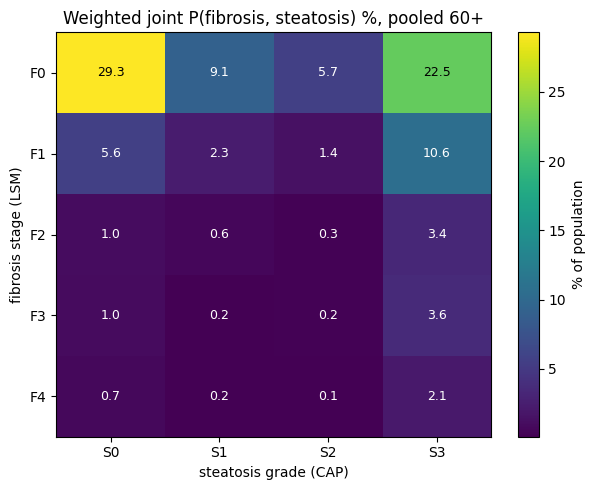

Per-demographic-cell joint categories (200 = 10 cells x 20):
  = 0 obs :  17 (8%)
  < 5 obs :  79 (40%)
  < 10 obs: 107 (54%)
  median count per joint category: 8
-> the two marginals are well estimated; the joint interior at fine
   demographic resolution is thin and needs smoothing or coarser bins.


In [2]:
# pooled weighted joint P(F,S)
T = np.zeros((5, 4))
for f in range(5):
    for s in range(4):
        T[f, s] = d.loc[(d.F == f) & (d.S == s), 'MEC_WT_POOL'].sum()
Pjoint = T / T.sum()

fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(Pjoint * 100, cmap='viridis', aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(SGRD)
ax.set_yticks(range(5)); ax.set_yticklabels(FSTG)
ax.set_xlabel('steatosis grade (CAP)'); ax.set_ylabel('fibrosis stage (LSM)')
ax.set_title('Weighted joint P(fibrosis, steatosis) %, pooled 60+')
for f in range(5):
    for s in range(4):
        ax.text(s, f, f'{Pjoint[f, s]*100:.1f}', ha='center', va='center',
                color='white' if Pjoint[f, s] * 100 < 12 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='% of population'); fig.tight_layout(); plt.show()

# sparsity at per-demographic-cell resolution (unweighted counts)
flat = []
for s, a in CELLS_DEMO:
    sub = d[(d.sex == s) & (d.age_start == a)]
    flat.extend(((sub.F == f) & (sub.S == g)).sum() for f in range(5) for g in range(4))
flat = np.array(flat)
print(f'Per-demographic-cell joint categories (200 = 10 cells x 20):')
print(f'  = 0 obs : {(flat == 0).sum():3d} ({100*(flat==0).mean():.0f}%)')
print(f'  < 5 obs : {(flat < 5).sum():3d} ({100*(flat<5).mean():.0f}%)')
print(f'  < 10 obs: {(flat < 10).sum():3d} ({100*(flat<10).mean():.0f}%)')
print(f'  median count per joint category: {np.median(flat):.0f}')
print('-> the two marginals are well estimated; the joint interior at fine')
print('   demographic resolution is thin and needs smoothing or coarser bins.')


## 2. Do we need the *joint*, or would independent marginals do?

If fibrosis and steatosis were independent, `P(F,S) = P(F)P(S)` and we could store
two marginals. They are moderately associated -- steatosis prevalence rises with
fibrosis and then dips at F4 ("burnt-out NASH", where fat regresses as cirrhosis
sets in) -- so the joint carries real signal a product of marginals would miss.


weighted Spearman(LSM, CAP): 0.310
Cramer's V (F x S):          0.150   (0 indep, ~0.1 weak, ~0.3 moderate)



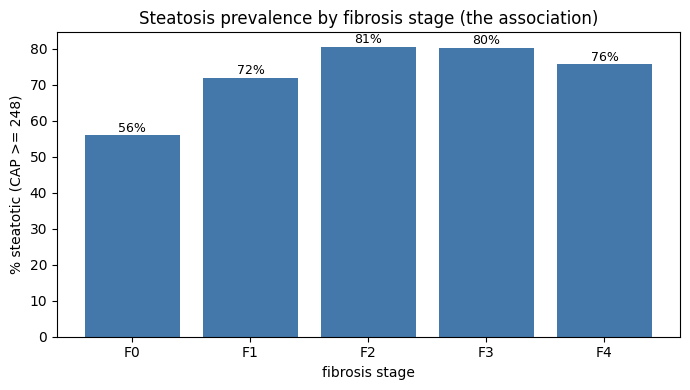

fibrosis    n  steatosis_S1plus
      F0 3287              56.0
      F1 1002              71.9
      F2  295              80.6
      F3  260              80.3
      F4  161              75.7


In [3]:
def w_spearman(x, y, w):
    w = w / w.sum()
    rx, ry = pd.Series(x).rank().values, pd.Series(y).rank().values
    mx, my = (w * rx).sum(), (w * ry).sum()
    cov = (w * (rx - mx) * (ry - my)).sum()
    return cov / np.sqrt((w * (rx - mx) ** 2).sum() * (w * (ry - my) ** 2).sum())

w = d.MEC_WT_POOL.values
rho = w_spearman(d.LSM_KPA.values, d.CAP_DBM.values, w)
row, col = Pjoint.sum(1, keepdims=True), Pjoint.sum(0, keepdims=True)
indep = row @ col
neff = L.n_eff(w)
cramers_v = np.sqrt((neff * np.sum((Pjoint - indep) ** 2 / indep)) / (neff * (min(5, 4) - 1)))
print(f'weighted Spearman(LSM, CAP): {rho:.3f}')
print(f"Cramer's V (F x S):          {cramers_v:.3f}   (0 indep, ~0.1 weak, ~0.3 moderate)")
print()
rows = []
for f in range(5):
    sub = d[d.F == f]
    rows.append(dict(fibrosis=FSTG[f], n=len(sub),
                     steatosis_S1plus=L.w_share_above(sub.CAP_DBM.values, sub.MEC_WT_POOL.values, CAPC[0])))
assoc = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(assoc.fibrosis, assoc.steatosis_S1plus * 100, color='#4477aa')
ax.set_ylabel('% steatotic (CAP >= 248)'); ax.set_xlabel('fibrosis stage')
ax.set_title('Steatosis prevalence by fibrosis stage (the association)')
for i, v in enumerate(assoc.steatosis_S1plus):
    ax.text(i, v * 100 + 1, f'{v*100:.0f}%', ha='center', fontsize=9)
fig.tight_layout(); plt.show()
print(assoc.assign(steatosis_S1plus=(assoc.steatosis_S1plus * 100).round(1)).to_string(index=False))


## 3. Stage-share fidelity: categorical is exact; the lognormal is not

The categorical layer stores the empirical stage shares, so it reproduces fibrosis
prevalence exactly (0 error). The single continuous lognormal misses -- overshooting
F2 (the 8-10 kPa shoulder) and badly undershooting F4 (the >=15 kPa tail).


stage  empirical = categorical  continuous lognormal  lognormal error (pp)
   F0                    66.58                 67.58                  1.01
   F1                    19.96                 19.77                 -0.19
   F2                     5.35                  7.93                  2.58
   F3                     5.03                  4.28                 -0.75
   F4                     3.09                  0.44                 -2.65


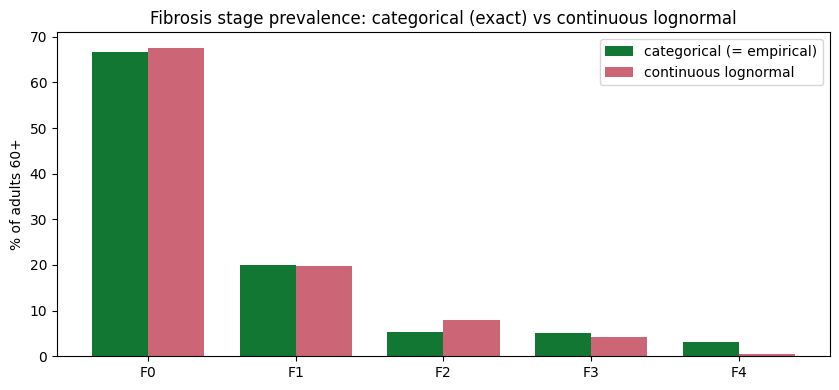


lognormal: F4 = 0.4% vs empirical 3.1%  (categorical reproduces 3.1% exactly)


In [4]:
W = 0.0; emp_v = np.zeros(5); ln_v = np.zeros(5)
for s, a in CELLS_DEMO:
    sub = d[(d.sex == s) & (d.age_start == a)]
    wc = sub.MEC_WT_POOL.sum(); W += wc
    emp_v += wc * L.empirical_stage_shares(sub.LSM_KPA.values, sub.MEC_WT_POOL.values, CUTS)
    r = new[(new.sex == s) & (new.age_start == a)].iloc[0]
    mu, sg = L.arith_to_lognorm(r.mean_kpa, r.sd_kpa)
    ln_v += wc * L.lognorm_stage_shares(mu, sg, CUTS)
emp_v /= W; ln_v /= W
comp = pd.DataFrame({'stage': FSTG, 'empirical = categorical': emp_v * 100,
                     'continuous lognormal': ln_v * 100,
                     'lognormal error (pp)': (ln_v - emp_v) * 100})
print(comp.round(2).to_string(index=False))

x = np.arange(5); wbar = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(x - wbar/2, emp_v * 100, wbar, color='#117733', label='categorical (= empirical)')
ax.bar(x + wbar/2, ln_v * 100, wbar, color='#cc6677', label='continuous lognormal')
ax.set_xticks(x); ax.set_xticklabels(FSTG); ax.set_ylabel('% of adults 60+')
ax.set_title('Fibrosis stage prevalence: categorical (exact) vs continuous lognormal')
ax.legend(); fig.tight_layout(); plt.show()
print(f"\nlognormal: F4 = {ln_v[4]*100:.1f}% vs empirical {emp_v[4]*100:.1f}%  "
      f"(categorical reproduces {emp_v[4]*100:.1f}% exactly)")


## 4. Within-stage spread: why the F4 tail is the whole story

The within-stage LSM ranges show why a single continuous fit can't win: F0-F3 sit
in narrow intervals, but **F4 spans ~15 to ~73 kPa** (mean ~31). A lognormal
centred near 5-6 kPa emits essentially no mass there, so it cannot produce a
cirrhosis-range measurement at all. A within-F4 distribution can.


stage interval    n  P10  mean  P90
   F0  [1.5,6) 3287  3.3   4.4  5.6
   F1    [6,8) 1002  6.1   6.7  7.6
   F2   [8,10)  295  8.1   8.7  9.5
   F3  [10,15)  260 10.2  11.7 13.5
   F4  [15,75)  161 15.7  30.7 72.8


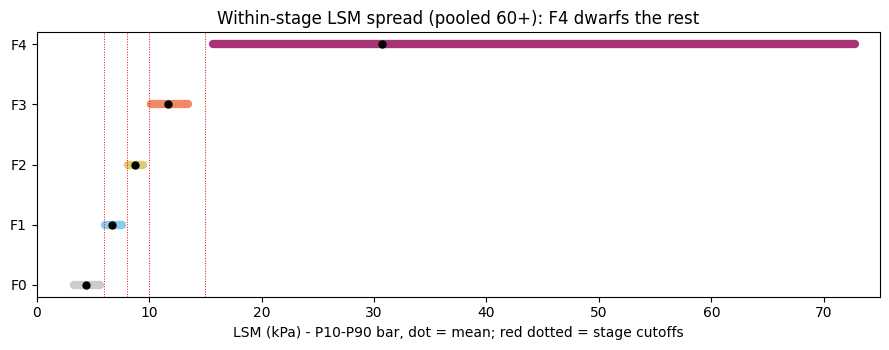

In [5]:
rows = []
for f in range(5):
    sub = d[d.F == f]; y, wt = sub.LSM_KPA.values, sub.MEC_WT_POOL.values
    rows.append(dict(stage=FSTG[f], interval=f'[{FED[f]:g},{FED[f+1]:g})', n=len(sub),
                     P10=L.w_quantile(y, wt, .1), mean=L.w_mean(y, wt),
                     P90=L.w_quantile(y, wt, .9)))
within = pd.DataFrame(rows)
print(within.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
colors = ['#cccccc', '#88ccee', '#ddcc77', '#ee8866', '#aa3377']
for i, r in within.iterrows():
    ax.plot([r.P10, r.P90], [i, i], color=colors[i], lw=6, solid_capstyle='round')
    ax.plot(r['mean'], i, 'o', color='black', ms=5)
for c in CUTS:
    ax.axvline(c, color='red', ls=':', lw=0.7)
ax.set_yticks(range(5)); ax.set_yticklabels(within.stage)
ax.set_xlabel('LSM (kPa) - P10-P90 bar, dot = mean; red dotted = stage cutoffs')
ax.set_title('Within-stage LSM spread (pooled 60+): F4 dwarfs the rest')
ax.set_xlim(0, 75); fig.tight_layout(); plt.show()


## 5. Marginal shape: single lognormal vs the stage-mixture

Reconstruct the full LSM distribution as the mixture `sum_s share_s x (truncated
lognormal within stage s)` -- the two-level model's implied marginal -- and compare
its weighted KS to the empirical CDF against the single lognormal we ship. The
mixture is also internally consistent: re-binning a within-stage draw recovers its
stage exactly.


mean weighted KS to empirical LSM CDF (lower = better):
  single lognormal (shipped) : 0.115  (max 0.179)
  stage-mixture (two-level)  : 0.037  (max 0.048)


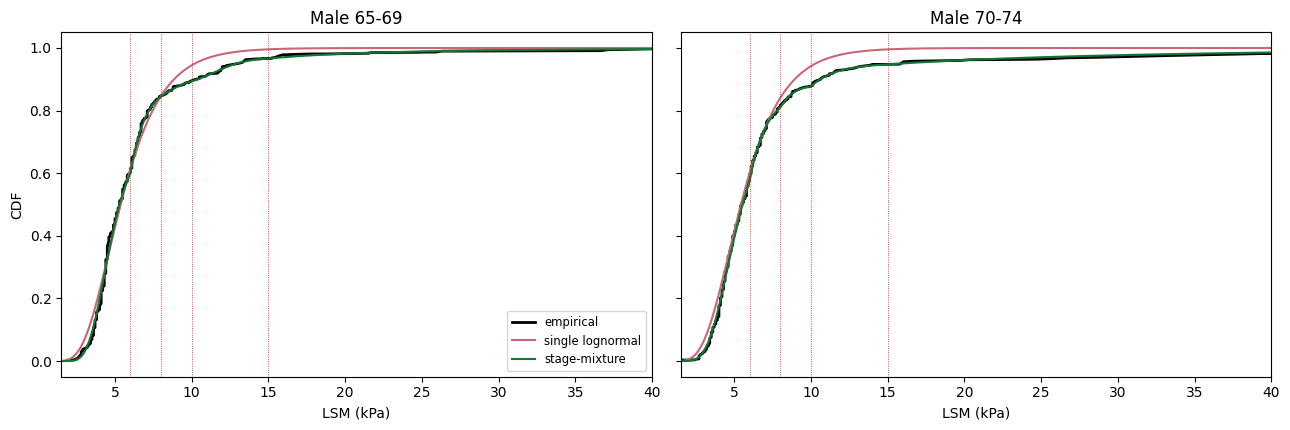

In [6]:
ks_single, ks_mix = [], []
demo_params = {}
for s, a in CELLS_DEMO:
    sub = d[(d.sex == s) & (d.age_start == a)]
    y, wt = sub.LSM_KPA.values.astype(float), sub.MEC_WT_POOL.values.astype(float)
    r = new[(new.sex == s) & (new.age_start == a)].iloc[0]
    mu, sg = L.arith_to_lognorm(r.mean_kpa, r.sd_kpa)
    ks_single.append(L.weighted_ks(y, wt, lambda v: stats.lognorm.cdf(v, sg, scale=np.exp(mu))))
    shares = L.empirical_stage_shares(y, wt, CUTS)
    params = []
    for f in range(5):
        m = (y >= FED[f]) & (y < FED[f + 1])
        params.append(L.fit_truncated_lognorm(y[m], wt[m], FED[f], FED[f + 1]))
    demo_params[(s, a)] = (shares, params)
    ks_mix.append(L.weighted_ks(y, wt, lambda v: L.stage_mixture_cdf(v, shares, params, FED)))
print('mean weighted KS to empirical LSM CDF (lower = better):')
print(f'  single lognormal (shipped) : {np.mean(ks_single):.3f}  (max {np.max(ks_single):.3f})')
print(f'  stage-mixture (two-level)  : {np.mean(ks_mix):.3f}  (max {np.max(ks_mix):.3f})')

# CDF overlay for two illustrative male cells (where the tail bites hardest)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (sx, ag) in zip(axes, [('Male', 65.0), ('Male', 70.0)]):
    sub = d[(d.sex == sx) & (d.age_start == ag)]
    y, wt = sub.LSM_KPA.values, sub.MEC_WT_POOL.values
    o = np.argsort(y); ax.plot(y[o], np.cumsum(wt[o]) / wt.sum(), 'k', lw=2, label='empirical')
    r = new[(new.sex == sx) & (new.age_start == ag)].iloc[0]
    mu, sg = L.arith_to_lognorm(r.mean_kpa, r.sd_kpa)
    grid = np.linspace(1.5, 40, 300)
    ax.plot(grid, stats.lognorm.cdf(grid, sg, scale=np.exp(mu)), '#cc6677', label='single lognormal')
    shares, params = demo_params[(sx, ag)]
    ax.plot(grid, L.stage_mixture_cdf(grid, shares, params, FED), '#117733', label='stage-mixture')
    for c in CUTS:
        ax.axvline(c, color='red', ls=':', lw=0.6)
    ax.set_title(f'{sx} {int(ag)}-{int(ag)+4}'); ax.set_xlabel('LSM (kPa)'); ax.set_xlim(1.5, 40)
axes[0].set_ylabel('CDF'); axes[0].legend(fontsize='small'); fig.tight_layout(); plt.show()


## 6. End-to-end sampler demo

The generative model in practice: draw a category from the joint `P(F,S)`, then a
measurement from the within-stage truncated distribution. We draw 50k simulants
from the pooled 60+ joint and confirm (a) recovered stage prevalence matches
empirical and (b) sampled LSM spans the full range, cirrhosis included -- neither
of which the single lognormal delivers.


In [7]:
rng = np.random.default_rng(0)
# within-stage LSM params (pooled 60+) and joint category probabilities
Fparams = []
for f in range(5):
    m = (d.F == f)
    Fparams.append(L.fit_truncated_lognorm(d.LSM_KPA[m].values, d.MEC_WT_POOL[m].values, FED[f], FED[f + 1]))
probs = Pjoint.flatten()
idx = rng.choice(20, size=50000, p=probs / probs.sum())
Fs, Ss = idx // 4, idx % 4
lsm_draw = np.empty(50000)
for f in range(5):
    sel = Fs == f
    if sel.any():
        lsm_draw[sel] = L.truncated_lognorm_rvs(*Fparams[f], FED[f], FED[f + 1], sel.sum(), rng)

emp_share = L.empirical_stage_shares(d.LSM_KPA.values, d.MEC_WT_POOL.values, CUTS)
sim_share = np.array([(np.clip(np.digitize(lsm_draw, CUTS), 0, 4) == f).mean() for f in range(5)])
print('Fibrosis prevalence: empirical vs 50k-simulant draw:')
print(pd.DataFrame({'stage': FSTG, 'empirical': (emp_share * 100).round(1),
                    'sampled': (sim_share * 100).round(1)}).to_string(index=False))
print(f'\nsampled LSM: min {lsm_draw.min():.1f}, median {np.median(lsm_draw):.1f}, '
      f'P99 {np.percentile(lsm_draw, 99):.1f}, max {lsm_draw.max():.1f} kPa')
print(f'share of draws in cirrhosis range (>=15 kPa): {(lsm_draw >= 15).mean()*100:.1f}% '
      f'(single lognormal produced ~0.4%)')


Fibrosis prevalence: empirical vs 50k-simulant draw:
stage  empirical  sampled
   F0       66.6     66.4
   F1       20.0     20.5
   F2        5.3      5.2
   F3        5.0      4.9
   F4        3.1      3.1

sampled LSM: min 1.5, median 5.1, P99 30.8, max 74.8 kPa
share of draws in cirrhosis range (>=15 kPa): 3.1% (single lognormal produced ~0.4%)


## Findings and recommendation

**The two-level model represents mild and severe fibrosis decisively better.**

| | single lognormal (shipped) | categorical + conditional |
| --- | --- | --- |
| F1/F2/F3 stage-share error | ~1.2 pp mean (F2 +2.6) | **0 (exact)** |
| Modeled cirrhosis (F4) prevalence | ~0.4% vs 3.1% empirical | **3.1% (exact)** |
| Marginal LSM fit (weighted KS) | ~0.115 | **~0.037** |
| Cirrhosis-range measurements | ~none possible | represented (F4 spans 15-73 kPa) |
| Internal consistency (re-bin recovers stage) | approximate | **exact** |

**Why it works:** the categorical layer sets the routing fractions exactly, and the
within-stage layer supplies a measurement -- crucially for F4, whose enormous
within-stage spread a single lognormal cannot reach.

**Costs to manage:**

1. **Joint-cell sparsity.** A full 5x4 joint per (sex, 5-yr age) cell is ~54%
   under 10 obs. The two stage *marginals* are well estimated; the association is
   only moderate (Spearman 0.31, Cramer's V 0.15). So prefer **marginals + a
   dependence component** (a rank copula on F/S, or a smoothed / shrunk joint)
   over 200 raw cells -- or coarsen to 10-year age bands.
2. **Within-F4 tail model.** The gain concentrates in F4; give it a heavy-tailed
   within-stage distribution on [15, 75] kPa (truncated lognormal here; a
   generalized Pareto would fit the tail even better). F0-F3 are near-deterministic
   given the stage.
3. **Downstream change.** This replaces the `(mean_kpa, sd_kpa)` lognormal contract:
   the exposure component in `vivarium_csu_mace_rct` must sample a category from
   `P(F,S)` then draw `LSM|F` and `CAP|S`. That is the real price, and the reason
   this was out of scope for the shipped tables.

**Recommendation.** Pursue the two-level model if cirrhosis-routing accuracy and a
faithful severe-fibrosis tail matter. Estimate the joint via marginals + a
dependence term (not a raw 200-cell table), use a heavy-tailed within-F4 model, and
budget for the downstream sampler change. The shipped continuous tables remain the
right choice only while the loader is fixed to a lognormal `(mean, sd)`.

*Coming back to this:* the reusable pieces live in `lsm_cap_fit.py`
(`fit_truncated_lognorm`, `truncated_lognorm_cdf`, `truncated_lognorm_rvs`,
`stage_mixture_cdf`, `stage_edges`); this notebook is the standalone evaluation.
